# 📘Домашнє завдання №9 Описовий аналіз даних (Exploratory Data Analysis)

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW9

Використати вбудований датасет:

In [1]:
# Download data (to cover the case when the data aren't accessible)

# !pip install --upgrade nbformat
# !pip install jinja2

import shutil
import sqlite3
import pandas as pd
import seaborn as sns
from pathlib import Path

from IPython.core.display import Markdown
from IPython.display import display
from pandas.io.formats.style import Styler

# Input data
ds_name = "iris"
db_file_name = "store_hw9.db"
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW9.git"
main_file_name = "Bohdan_Pinchuk_DS_HW9.ipynb"

# Solution

# Note: to handle error: "SSL: CERTIFICATE_VERIFY_FAILED" or no connection to the server
try:
    # for testing
    # raise Exception
    ds_data = sns.load_dataset(ds_name)

    # Use only one time to initialize/update data (at first time)
    # conn = sqlite3.connect(db_file_name)
    # ds_data.to_sql(ds_name, conn, if_exists="replace", index=False)
    # conn.close()
except Exception:
    file_path = Path(db_file_name)

    if not file_path.exists():
        # upload all files
        current_path = !pwd
        current_path = current_path[0]
        parent_path = !dirname "$current_path"
        parent_path = parent_path[0]
        temp_path = f"{parent_path}/temp"

        # Clone data
        !rm -rf "$temp_path"
        !git clone "$git_project_url" "$temp_path"

        source = Path(temp_path)
        destination = Path(current_path)
        exclude = {main_file_name, ".git", ".idea"}

        for item in source.iterdir():
            if item.name in exclude:
                continue

            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

        # Clean temp folder
        !rm -rf "$temp_path"

    conn = sqlite3.connect(db_file_name)
    ds_data = pd.read_sql(f"SELECT * FROM {ds_name}", conn)
    conn.close()

# display(ds_data)

In [2]:
import numpy as np
import pandas as pd
import jinja2


class Reporter:
    """
    Class for collecting and printing data in tabular form
    """

    def __init__(self, attribute_col: str = "Attribute", result_col: str = "Result"):
        self._border_sign = "#"
        self._hor_split_sign = "~"
        self._ver_split_sign = "|"
        self._tolerance = 4
        self._max_len_lf: int = 0
        self._max_len_rt: int = 0
        self._data_list: list[tuple[str, str]] = []
        self.attribute_col = attribute_col
        self.result_col = result_col

    @property
    def max_len_lf(self) -> int:
        """Maximum left column width (the 1st column)"""
        return self._max_len_lf

    @property
    def max_len_rt(self) -> int:
        """Maximum right column width (the 2nd column)"""
        return self._max_len_rt

    @property
    def data_list(self) -> list[tuple[str, str]]:
        """The list of data to be printed"""
        return self._data_list

    @property
    def border_sign(self) -> str:
        """Character used for the outside table border"""
        return self._border_sign

    @border_sign.setter
    def border_sign(self, value: str) -> None:
        self._border_sign = value

    @property
    def hor_split_sign(self) -> str:
        """Character used for horizontal splitter in tabular form"""
        return self._hor_split_sign

    @hor_split_sign.setter
    def hor_split_sign(self, value: str) -> None:
        self._hor_split_sign = value

    @property
    def ver_split_sign(self) -> str:
        """Character used for vertical splitter in tabular form"""
        return self._ver_split_sign

    @ver_split_sign.setter
    def ver_split_sign(self, value: str) -> None:
        self._ver_split_sign = value

    @property
    def tolerance(self) -> int:
        """Number of digits after the floating point"""
        return self._tolerance

    @tolerance.setter
    def tolerance(self, value: int) -> None:
        self._tolerance = value

    @property
    def attribute_col(self) -> str:
        """Name of the attribute (the 1st column)"""
        return self._attribute_col

    @attribute_col.setter
    def attribute_col(self, value: str) -> None:
        array_str_key = value.splitlines()
        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))
        self._attribute_col = value

    @property
    def result_col(self) -> str:
        """Name of the result (the 2nd column)"""
        return self._result_col

    @result_col.setter
    def result_col(self, value: str) -> None:
        array_str_value = value.splitlines()
        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))
        self._result_col = value

    def format_value(self, value: float) -> str:
        """
        Format value to string
        :param value: input value
        :return: string of the value
        """
        return f"{value:.{self.tolerance}f}"

    def format_matrix(self, matrix: np.ndarray) -> str:
        """
        Formatting matrix into string
        :param matrix: input matrix
        :return: string of the matrix
        """
        return np.array2string(matrix, precision=self.tolerance)

    def add_item(self, key: str, value: str) -> None:
        """
        Form the report data that consist multi strings
        :param key: attribute
        :param value: result
        """
        array_str_key = key.splitlines()
        array_str_value = value.splitlines()

        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))

        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))

        self._data_list.append((key, value))

    def _print_line_splitter(self, sign: str = "-") -> None:
        """
        Print line splitter
        """
        print(sign * (self.max_len_lf + self.max_len_rt + 5))

    def _print_multi_string(self, row: tuple[str, str]) -> None:
        """
        Print the multi string
        :param row: tuple of data
        """
        array_str_key = row[0].splitlines()
        array_str_value = row[1].splitlines()
        num_str = max(len(array_str_key), len(array_str_value))

        for index in range(num_str):
            if index < len(array_str_key):
                left_str = f"{f"{array_str_key[index]}":<{self.max_len_lf}}"
            else:
                left_str = f"{f" ":<{self.max_len_lf}}"

            if index < len(array_str_value):
                right_str = f"{f"{array_str_value[index]:<{self.max_len_rt}}"}"
            else:
                right_str = f"{f" ":<{self.max_len_rt}}"

            print(f" {left_str} {self.ver_split_sign} {right_str}")

    def refresh_table_config(self) -> None:
        """
        Refresh table configuration, like line lengths
        :return:
        """
        self._max_len_lf = 0
        self._max_len_rt = 0

        self.attribute_col = self.attribute_col
        self.result_col = self.result_col

        temp_data_list = self.data_list
        self._data_list = []
        for temp_data in temp_data_list:
            self.add_item(temp_data[0], temp_data[1])

    def print_report(self) -> None:
        """
        Print report data
        """
        self._print_line_splitter(self.border_sign)
        self._print_multi_string((self.attribute_col, self.result_col))
        self._print_line_splitter(self.border_sign)
        for item_data in self.data_list[0:-1]:
            self._print_multi_string(item_data)
            self._print_line_splitter("~")
        self._print_multi_string(self.data_list[-1])
        self._print_line_splitter(self.border_sign)

    def print_refreshed_report(self) -> None:
        """
        Print report data with a refreshing table
        """
        self.refresh_table_config()
        self.print_report()

    def get_pd_report(self) -> Styler:
        """
        Generate report data using pandas dataframe
        """
        df_data_list = pd.DataFrame(self.data_list, columns=[self.attribute_col, self.result_col])
        pd.set_option('display.max_colwidth', None)
        df_data_list = (df_data_list.style.hide(axis='index')
        .set_properties(**{
            'text-align': 'left',
            'white-space': 'pre-wrap',
            'border': '1px solid lightgrey'
        }).set_table_styles([  # type: ignore
            {"selector": "th", "props": [("text-align", "left")]}
        ]))
        return df_data_list

    def print_pd_report(self) -> None:
        """
        Print report data using pandas dataframe
        """
        df_data_list = self.get_pd_report()
        display(df_data_list)


In [3]:
## Отримання даних

# Solution
iris = ds_data.copy()

# Print results
display(iris)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Датасет дані про квіти ірисів трьох видів:
* Setosa
* Versicolor
* Virginica

Для кожної квітки виміряно 4 числові характеристики:
* `sepal_length` — довжина чашолистка
* `sepal_width` — ширина чашолистка
* `petal_length` — довжина пелюстки
* `petal_width` — ширина пелюстки

Цільова змінна:
* `species` — вид квітки (категоріальна змінна)

# Завдання (за етапами EDA)
1. Ознайомлення з даними
* Вивести перші 5 рядків
* Визначити:
  * кількість рядків і стовпців
  * назви колонок
  * типи даних
* Питання:
  * Скільки об’єктів у датасеті?
  * Скільки ознак?
2. Розуміння змінних
* Визначити:
  * числові змінні
  * категоріальні змінні
  * Визначити "цільову змінну"
* Питання:
  * Яка змінна є цільовою?
  * Які змінні описують об’єкти?
3. Перевірка пропущених значень
* Перевірити наявність пропусків
* Питання:
  * Чи є пропущені значення?
  * Якщо є — що з ними робити?
4. Описова статистика
* Вивести статистику для числових змінних
* Питання:
  * Яка ознака має найбільше середнє значення?
  * Чи є сильні відмінності між ознаками?
5. Аналіз категоріальних змінних
* Визначити кількість об’єктів кожного класу
* Питання:
  * Чи збалансований датасет (чи класи розподілені приблизно порівну)?
6. Аналіз розподілів
* Побудувати гістограми для всіх числових змінних
* Побудувати boxplot
* Питання:
  * Чи є викиди?
  * Які розподіли (симетричні чи ні)?
7. Аналіз цільової змінної
* Візуалізувати розподіл класів
* Питання:
  * Який клас найчастіший?
8. Біваріантний аналіз
* Побудувати:
  * scatterplot між ознаками
  * boxplot (ознака vs клас)
* Питання:
  * Які ознаки найкраще розділяють класи?
9. Кореляційний аналіз
* Побудувати кореляційну матрицю
* Питання:
  * Які змінні сильно корелюють?
  * Чи є надлишкові ознаки?
10. Зведені таблиці (Pivot Tables)
* Побудувати середні значення ознак по класах
* Питання:
  * Як відрізняються класи між собою?
11. Виявлення закономірностей
* Описати:
  * які ознаки найважливіші
  * як відрізняються класи
12. Висновки
* Написати висновки:
  * про структуру даних
  * про залежності

In [4]:
# 1. Ознайомлення з даними

import numpy as np
import pandas as pd

# Input data
n_first_rows = 5

# Solution
display(Markdown(f"""
### 1. Ознайомлення з даними
"""))

display(Markdown(f"""
---
Виведення перших {n_first_rows} рядків:
"""), iris.head(n_first_rows))

n_columns = iris.columns.size
n_rows = iris.index.size
columns_df = pd.DataFrame(iris.columns, columns=["Columns"])
types_df = pd.DataFrame(iris.dtypes, columns=["Types"])

rp = Reporter()
rp.add_item("Кількість рядків", str(iris.index.size))
rp.add_item("Кількість стовпців", str(iris.columns.size))

display(Markdown(f"""
---
Параметри таблиці:
"""), rp.get_pd_report())

display(Markdown(f"""
* Назви колонок:
"""), columns_df.style.hide(axis='index'))

display(Markdown(f"""
* Типи даних:
"""), types_df)

col_num_type = iris.select_dtypes(include=np.number).columns
col_cat_type = iris.select_dtypes(exclude=np.number).columns

rp = Reporter()
rp.add_item("Кількість об’єктів у датасеті", str(iris.index.size))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report(), Markdown("---"))


### 1. Ознайомлення з даними



---
Виведення перших 5 рядків:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



---
Параметри таблиці:


Attribute,Result
Кількість рядків,150
Кількість стовпців,5


...


* Типи даних:


,Types
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,str



---
Відповіді:

Attribute,Result
Кількість об’єктів у датасеті,150
Кількість числових ознак,4
Кількість категоріальних ознак,1


---

In [5]:
# 2. Розуміння змінних

import pandas as pd

# Input data

# Solution
col_num_type_df = pd.DataFrame(col_num_type, columns=["Numeric variables"])
col_cat_type_df = pd.DataFrame(col_cat_type, columns=["Categorical variables"])

display(Markdown(f"""
### 2. Розуміння змінних
"""))

display(Markdown(f"""
---
Визначення:
* Числові змінні:
"""), col_num_type_df.style.hide(axis='index'))

cat_types = iris.select_dtypes(exclude=['str']).columns
col_targ_type_df = pd.DataFrame(col_cat_type, columns=["Target variables"])

display(Markdown(f"""
* Категоріальні змінні:
"""), col_cat_type_df.style.hide(axis='index'))

display(Markdown(f"""
* Цільова зміна:
"""), col_targ_type_df.style.hide(axis='index'))

display(Markdown(f"""
**Примітка**

> Числові змінні - це змінні, які відображають характеристики обʼєкта, його результати, величину впливу на нього тощо. Аналогія: поля ініціалізованого об'єкта.

> Категоріальні змінні - це змінні, що описують обʼєкт відносячи його до певної групи, або ж це групи, поділені за певними діапазонами ознак. Аналогії: 1. бази даних SQL, в якій дочірня таблиця містить у собі зовнішній ключ (подібно до назви групи) і використовується в мастер-таблиці. 2. Enum (типи значень в Java, C#), які несуть у собі певне пояснення у відмінності, або ж як interface (інтерфейс в Java, C#) або абстрактний клас в Python, де при наслідуванні клас наслідує поведінку та деякі характеристики, якщо це передбачено.

> Цільові змінні - це змінні, які описують очікуваний вихідний/прогнозований результат залежно від ознак, тобто назва групи/категорії. Якщо обрати одну з категоріальних змінних і розглянути саме її структуру, то в цьому об'єктові представлення/назва/мітка/ID і буде цільовою змінною. Аналогія: клас ініціалізованого обʼєкта з усіма необхідними полями та наслідуванням від необхідних абстрактних класів.

> Структура: вхідні параметри — це числові й категоріальні змінні, а вихідний результат - цільова змінна. Наприклад: ```def function(*числові та категоріальні змінні) -> (цільові змінні):```
"""))

rp = Reporter()
rp.add_item("Цільовою змінною є", str(',\n'.join(col_targ_type_df['Target variables'].astype(str))))
rp.add_item("Змінними, які описують обʼєкт є", str(',\n'.join(col_num_type_df['Numeric variables'].astype(str))))

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report(), Markdown("---"))


### 2. Розуміння змінних



---
Визначення:
* Числові змінні:


Numeric variables
sepal_length
sepal_width
petal_length
petal_width



* Категоріальні змінні:


Categorical variables
species


...

Target variables
species



**Примітка**

> Числові змінні - це змінні, які відображають характеристики обʼєкта, його результати, величину впливу на нього тощо. Аналогія: поля ініціалізованого об'єкта.

> Категоріальні змінні - це змінні, що описують обʼєкт відносячи його до певної групи, або ж це групи, поділені за певними діапазонами ознак. Аналогії: 1. бази даних SQL, в якій дочірня таблиця містить у собі зовнішній ключ (подібно до назви групи) і використовується в мастер-таблиці. 2. Enum (типи значень в Java, C#), які несуть у собі певне пояснення у відмінності, або ж як interface (інтерфейс в Java, C#) або абстрактний клас в Python, де при наслідуванні клас наслідує поведінку та деякі характеристики, якщо це передбачено.

> Цільові змінні - це змінні, які описують очікуваний вихідний/прогнозований результат залежно від ознак, тобто назва групи/категорії. Якщо обрати одну з категоріальних змінних і розглянути саме її структуру, то в цьому об'єктові представлення/назва/мітка/ID і буде цільовою змінною. Аналогія: клас ініціалізованого обʼєкта з усіма необхідними полями та наслідуванням від необхідних абстрактних класів.

> Структура: вхідні параметри — це числові й категоріальні змінні, а вихідний результат - цільова змінна. Наприклад: ```def function(*числові та категоріальні змінні) -> (цільові змінні):```



---
Відповіді:

Attribute,Result
Цільовою змінною є,species
"Змінними, які описують обʼєкт є","sepal_length, sepal_width, petal_length, petal_width"


---

In [6]:
# 3. Перевірка пропущених значень

# Input data

# Solution
empty_val_by_col = iris.isnull().sum().to_frame(name='Count')

display(Markdown(f"""
### 3. Перевірка пропущених значень
"""))

display(Markdown(f"""
---
Наявність пропусків:
* Пропуски в кожній колонці:
"""), empty_val_by_col)

is_empty_val = empty_val_by_col.values.sum() > 0

rp = Reporter()
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report())

display(Markdown(f"""
> Обробка пропущених значень: _На мою думку, пропущенні значення опрацьовуються залежно від їх цінності. Якщо обʼєктів у достатній кількості, а пропущених значень доволі мало та вимагається просто проглянути загальну картину без подальшого їх використання, то достатньо просто вилучити ці значення із таблиці ```dropna()```. Якщо ж обʼєктів мало, або якщо вони є критичними, тоді можна проаналізувати ознаку цієї колонки, якщо вона не є критичною і в цій колонці значна частина має пропуски, то замість видалення обʼєктів можна вилучити цю колонку ```drop(columns=['col_1',..., 'col_n'])```. Якщо ж сам обʼєкт загалом має багато пропусків, особливо по критичних ознаках, а також щоб він не вносив "шуму" в аналіз даних, то можна вилучити саме цей обʼєкт базуючись на критичних колонках ```dropna(subset=['col_1',..., 'col_n'])``` або на мінімальній кількості заповнених ознак ```dropna(thresh=n_existed_values)```. Якщо ж нвм критично необхідно заповнити декілька значень, то залежно від типу ознаки її смислу можна скористатися модою (найбільша частота), медіаною (центральне значення у відсортованому списку), середнім значенням (математичне очікування) тощо._
---
"""))


### 3. Перевірка пропущених значень



---
Наявність пропусків:
* Пропуски в кожній колонці:


,Count
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0



---
Відповіді:

Attribute,Result
Пропущені значення,немає



> Обробка пропущених значень: _На мою думку, пропущенні значення опрацьовуються залежно від їх цінності. Якщо обʼєктів у достатній кількості, а пропущених значень доволі мало та вимагається просто проглянути загальну картину без подальшого їх використання, то достатньо просто вилучити ці значення із таблиці ```dropna()```. Якщо ж обʼєктів мало, або якщо вони є критичними, тоді можна проаналізувати ознаку цієї колонки, якщо вона не є критичною і в цій колонці значна частина має пропуски, то замість видалення обʼєктів можна вилучити цю колонку ```drop(columns=['col_1',..., 'col_n'])```. Якщо ж сам обʼєкт загалом має багато пропусків, особливо по критичних ознаках, а також щоб він не вносив "шуму" в аналіз даних, то можна вилучити саме цей обʼєкт базуючись на критичних колонках ```dropna(subset=['col_1',..., 'col_n'])``` або на мінімальній кількості заповнених ознак ```dropna(thresh=n_existed_values)```. Якщо ж нвм критично необхідно заповнити декілька значень, то залежно від типу ознаки її смислу можна скористатися модою (найбільша частота), медіаною (центральне значення у відсортованому списку), середнім значенням (математичне очікування) тощо._
---


In [7]:
# 4. Описова статистика

import numpy as np

# Input data
contrast_level = 0.25
# Note. The value is only for example

# Solution
data_num_type_df = iris.select_dtypes(include=np.number)
data_cat_type_df = iris.select_dtypes(exclude=np.number)

display(Markdown(f"""
### 4. Описова статистика
"""))

target_value = col_targ_type_df['Target variables'].iloc[0]

display(Markdown(f"""
---
* Статистика для числових змінних:
"""), data_num_type_df.describe().T.style.set_caption("Totally"),
        iris.groupby([target_value]).describe().T.stack().unstack(level=1).style.set_caption("By category"))

display(Markdown(f"""
* Статистика для категоріальних змінних:
"""), data_cat_type_df.describe().T.style.set_caption("Totally"))


# Note. I used the "optical" contrast definition
def contrast(val1: np.number, val2: np.number) -> float:
    """
    Contrast between 2 values
    :param val1: first value
    :param val2: second value
    :return: result between 0 and 1
    """
    return abs(val1 - val2) / abs(val1 + val2) if (val1 + val2) != 0 else 0


sorted_data_num_type_df = data_num_type_df.mean().sort_values()
max_contrast = max([contrast(sorted_data_num_type_df.iloc[i], sorted_data_num_type_df.iloc[i + 1])
                    for i in range(len(sorted_data_num_type_df) - 1)])

rp = Reporter()
rp.add_item("Ознака з найбільшим середнім значенням", str(data_num_type_df.mean().idxmax()))
rp.add_item("Рівень відмінності між ознаками,\nпри якому він буде вважатиметься сильним", f"{contrast_level:.2%}")
rp.add_item("Сильні відмінності між ознаками\n(за дисперсією)", 'є' if max_contrast >= contrast_level else 'немає')
rp.add_item("Максимальна відмінність між ознаками\n(упорядкованими за дисперсією)", f"{max_contrast:.2%}")
rp.add_item("Ознака з найбільшою дисперсією\n(розкидом значень)", str(data_num_type_df.std().idxmax()))

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report(), Markdown("---"))



### 4. Описова статистика



---
* Статистика для числових змінних:


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.000000,5.843333,0.828066,4.300000,5.100000,5.800000,6.400000,7.900000
sepal_width,150.000000,3.057333,0.435866,2.000000,2.800000,3.000000,3.300000,4.400000
petal_length,150.000000,3.758000,1.765298,1.000000,1.600000,4.350000,5.100000,6.900000
petal_width,150.000000,1.199333,0.762238,0.100000,0.300000,1.300000,1.800000,2.500000



* Статистика для категоріальних змінних:


,count,unique,top,freq
species,150,3,setosa,50



---
Відповіді:

Attribute,Result
Ознака з найбільшим середнім значенням,sepal_length
"Рівень відмінності між ознаками, при якому він буде вважатиметься сильним",25.00%
Сильні відмінності між ознаками (за дисперсією),є
Максимальна відмінність між ознаками (упорядкованими за дисперсією),43.65%
Ознака з найбільшою дисперсією (розкидом значень),petal_length


---

In [8]:
# 5. Аналіз категоріальних змінних

# Input data
balans_level = 0.1
# Note. The value is only for example

# Solution
display(Markdown(f"""
### 5. Аналіз категоріальних змінних
"""))

display(Markdown(f"""
---
* Кількість об’єктів кожного класу:
"""), iris[target_value].value_counts().to_frame(name="Count"))

sorted_class_count = iris[target_value].value_counts().tolist()
max_contrast = contrast(min(sorted_class_count), max(sorted_class_count))

rp = Reporter()
rp.add_item("Рівень датасету,\nпри якому він буде вважатиметься збалансованим", f"{balans_level:.2%}")
rp.add_item("Датасет збалансований", 'так' if max_contrast <= balans_level else 'ні')
rp.add_item("Максимальна відмінність між класами", f"{max_contrast:.2%}")

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report(), Markdown("---"))


### 5. Аналіз категоріальних змінних



---
* Кількість об’єктів кожного класу:


,Count
species,
setosa,50
versicolor,50
virginica,50



---
Відповіді:

Attribute,Result
"Рівень датасету, при якому він буде вважатиметься збалансованим",10.00%
Датасет збалансований,так
Максимальна відмінність між класами,0.00%


---

In [9]:
# 6. Аналіз розподілів

import numpy as np
from scipy import signal
from scipy.stats import gaussian_kde

# Input data
smoothing = 0.25
n_points = 100

# Solution
x_array = []
y_array = []
mean_array = []
# Спроба описати симетричність через Фурʼє перетворення, яке знаходиться в згортці (кореляції), щоб побачити подібність сигналів,
# але треба ще попрацювати над коефіцієнтом нормування і запропонувати кращий його розрахунок
symmetry_coef = []
n_outliers = []

for col_name in data_num_type_df.columns:
    col_data = data_num_type_df[col_name].values
    mean_val = col_data.mean()
    mean_array.append(mean_val)

    density_data = gaussian_kde(col_data, bw_method=smoothing)
    x_data = np.linspace(col_data.min(), col_data.max(), n_points)
    x_array.append(x_data)
    y_data = density_data.evaluate(x_data)
    y_array.append(y_data)

    x_left = x_data[x_data <= mean_val]
    y_left = y_data[0:len(x_left)]
    y_right = y_data[len(x_left):]

    # Use the convolution to understand if the charts are similar
    norm_coef = np.sqrt((y_left ** 2).sum() * (y_right ** 2).sum())
    conv_coef = signal.fftconvolve(y_left, y_right, mode='full') / norm_coef
    symmetry_coef.append(conv_coef.max())

    # Calculating outliers
    Q1 = data_num_type_df[col_name].quantile(0.25)
    Q3 = data_num_type_df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = [value for value in col_data if value < lower_limit or value > upper_limit]
    n_outliers.append(len(outliers))

display(Markdown(f"""
### 6. Аналіз розподілів
"""))

rp = Reporter()
for i, col_name in enumerate(data_num_type_df.columns):
    rp.add_item(f"{col_name}, викиди", 'відсутні' if n_outliers[i] > 0 else 'наявні')
    rp.add_item(f"{col_name}, кількість викидів", str(n_outliers[i]))

display(Markdown(f"""
---
Відповіді:
* Викиди/outliers (по boxplot):
"""), rp.get_pd_report())

rp = Reporter()

for i, col_name in enumerate(data_num_type_df.columns):
    rp.add_item(f"{col_name}, розподіл", 'симетричний' if symmetry_coef[i] >= 0.95 else 'несиметричний')
    rp.add_item(f"{col_name}, коефіцієнт симетричності", f"{symmetry_coef[i]:.2%}")

display(Markdown(f"""
* Симетричність (по гістограмах):
"""), rp.get_pd_report(), Markdown("---"))


### 6. Аналіз розподілів



---
Відповіді:
* Викиди/outliers (по boxplot):


Attribute,Result
"sepal_length, викиди",наявні
"sepal_length, кількість викидів",0
"sepal_width, викиди",відсутні
"sepal_width, кількість викидів",4
"petal_length, викиди",наявні
"petal_length, кількість викидів",0
"petal_width, викиди",наявні
"petal_width, кількість викидів",0



* Симетричність (по гістограмах):


Attribute,Result
"sepal_length, розподіл",симетричний
"sepal_length, коефіцієнт симетричності",97.60%
"sepal_width, розподіл",симетричний
"sepal_width, коефіцієнт симетричності",99.50%
"petal_length, розподіл",несиметричний
"petal_length, коефіцієнт симетричності",79.43%
"petal_width, розподіл",несиметричний
"petal_width, коефіцієнт симетричності",79.70%


---

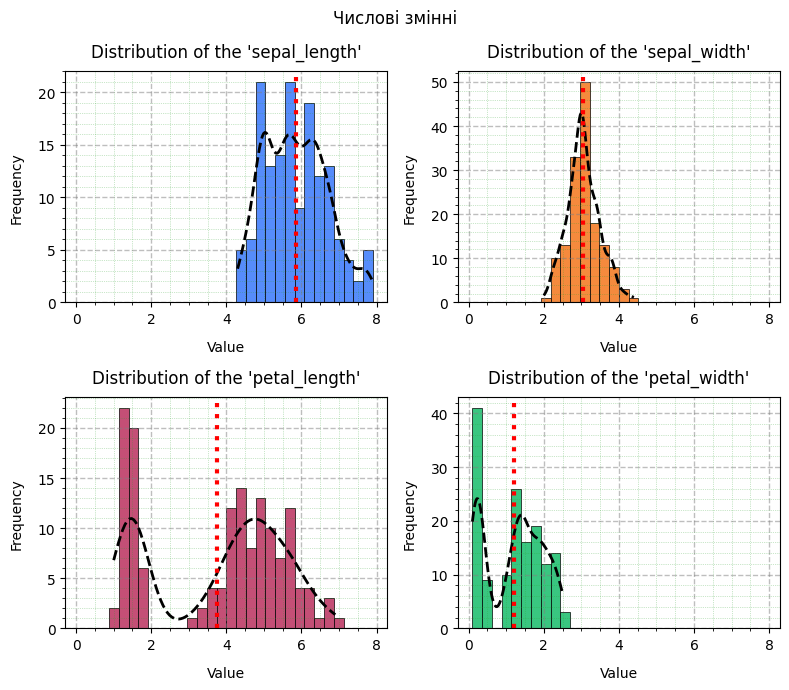

In [10]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_bins = 30
n_columns = 2

# Solution
axes = data_num_type_df.plot.hist(subplots=True, layout=(-1, n_columns), figsize=(8, 7),
                                  bins=n_bins, edgecolor="black", linewidth=0.5, sharex=False, sharey=False)

for i, ax in enumerate(axes.flatten()):
    legend_text = ax.get_legend().get_texts()[0].get_text()
    bin_width = ax.patches[0].get_width()
    counts = data_num_type_df[legend_text].count()
    scale_coef = bin_width * counts
    ax.plot(x_array[i], y_array[i] * scale_coef, color='black', linestyle='dashed', linewidth=2.0)

    ax.axvline(float(mean_array[i]), linestyle=':', color='red', linewidth=3.0)

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Distribution of the '{legend_text}'", pad=10, loc='center', color='black')
    ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')
    ax.get_legend().set_visible(False)

plt.suptitle("Числові змінні")

plt.tight_layout()
plt.show()

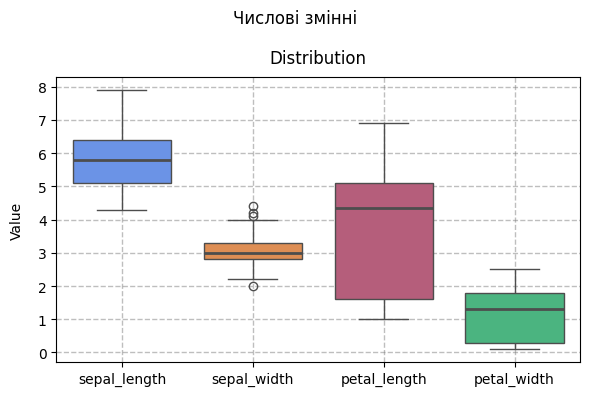

In [11]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data_num_type_df, ax=ax, width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle("Числові змінні")

plt.tight_layout()
plt.show()

In [12]:
# 7. Аналіз цільової змінної

# Input data

# Solution
display(Markdown(f"""
### 7. Аналіз цільової змінної
"""))

max_hit_rate = max(sorted_class_count)
classes_df = iris[target_value].value_counts().to_frame()
list_classes = classes_df[classes_df['count'] >= max_hit_rate].index.tolist()

rp = Reporter()
rp.add_item("Кількість обʼєктів у класах, які зʼявляється найчастіше", str(max_hit_rate))
rp.add_item("Класи з найчастішою появою обʼєктів", str(',\n'.join(list_classes)))

display(Markdown(f"""
---
Відповіді:"""), rp.get_pd_report(), Markdown("---"))


### 7. Аналіз цільової змінної



---
Відповіді:

Attribute,Result
"Кількість обʼєктів у класах, які зʼявляється найчастіше",50
Класи з найчастішою появою обʼєктів,"setosa, versicolor, virginica"


---

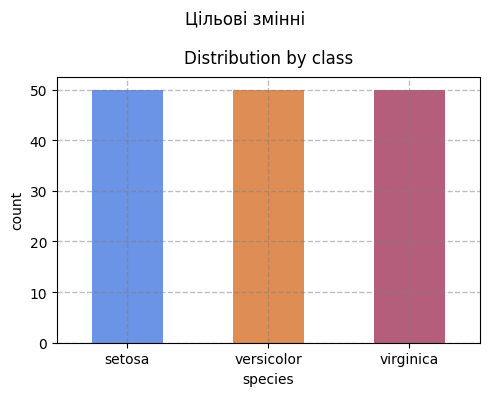

In [13]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(5, 4))

sns.countplot(data=data_cat_type_df, ax=ax, x=target_value, hue=target_value, width=0.5)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution by class", pad=10, loc='center', color='black')

plt.suptitle("Цільові змінні")

plt.tight_layout()
plt.show()

In [14]:
# 8. Біваріантний аналіз

# Примітка. Оскільки ми маємо 4 типи числових ознак, а нам потрібно це відобразити на графіках, то відповідно постає проблема їх відображення, через те, що необхідно використати 4-х вимірний простір, або реалізувати багато однотипних графіків.
# Аналізуючи предметну область, бачимо, що ми маємо по 2 характеристики 2-х обʼєктів, які умовно можна обʼєднати. Найбільш відповідна характеристика, за якою можна обʼєднати деякі ознаки, — це умовна проща обʼєкта. Припустимо, що ми маємо не абсолютні/реальні значення, а відносні, тобто матимуть умовно ознакову "розмірність", що добре для порівняння.

# Input data
list_characteristics = data_num_type_df.columns.tolist()
iris_melt_df = iris.melt(id_vars=target_value,
                         value_vars=list_characteristics,
                         var_name='feature',
                         value_name='value')

sepal_length_col_name = "sepal_length"
sepal_width_col_name = "sepal_width"
petal_length_col_name = "petal_length"
petal_width_col_name = "petal_width"
sepal_area_col_name = "sepal_area"
petal_area_col_name = "petal_area"

iris_area = iris.copy()
iris_area[sepal_area_col_name] = iris_area.apply(
    lambda df_row: df_row[sepal_length_col_name] * df_row[sepal_width_col_name], axis=1)
iris_area[petal_area_col_name] = iris_area.apply(
    lambda df_row: df_row[petal_width_col_name] * df_row[sepal_area_col_name], axis=1)
iris_area.drop(columns=list_characteristics, inplace=True)

iris_area_melt_df = iris_area.melt(id_vars=target_value,
                                   value_vars=[sepal_area_col_name, petal_area_col_name],
                                   var_name='feature',
                                   value_name='value')

# Solution
display(Markdown(f"""
### 8. Біваріантний аналіз
---
"""))

display(iris_melt_df)
display(iris_area)

display(Markdown(f"""
---
Відповіді:
> Ознаки "petal_length" і "petal_width" найкраще розділяють класти. Особливо помітно для класу "setosa", з іншими класами складніше, через те, що їх дані перетинаються.

> Застосувавши агрегацію даних для параметрів, було виділено нові ознаки (прощі). Аналіз регресійного графіка показав, що нові ознаки проявляють чіткі трендові лінії, що показують залежність між площею чашолистка та площею пелюстки. Аналіз графіка boxplot показав, що найкраще розділення класів помітно за ознакою "petal_area", оскільки вони не перетинаються.
---
"""))



### 8. Біваріантний аналіз
---


,species,feature,value
0,setosa,sepal_length,5.1
1,setosa,sepal_length,4.9
2,setosa,sepal_length,4.7
3,setosa,sepal_length,4.6
4,setosa,sepal_length,5.0
...,...,...,...
595,virginica,petal_width,2.3
596,virginica,petal_width,1.9
597,virginica,petal_width,2.0
598,virginica,petal_width,2.3


,species,sepal_area,petal_area
0,setosa,17.85,3.570
1,setosa,14.70,2.940
2,setosa,15.04,3.008
3,setosa,14.26,2.852
4,setosa,18.00,3.600
...,...,...,...
145,virginica,20.10,46.230
146,virginica,15.75,29.925
147,virginica,19.50,39.000
148,virginica,21.08,48.484



---
Відповіді:
> Ознаки "petal_length" і "petal_width" найкраще розділяють класти. Особливо помітно для класу "setosa", з іншими класами складніше, через те, що їх дані перетинаються.

> Застосувавши агрегацію даних для параметрів, було виділено нові ознаки (прощі). Аналіз регресійного графіка показав, що нові ознаки проявляють чіткі трендові лінії, що показують залежність між площею чашолистка та площею пелюстки. Аналіз графіка boxplot показав, що найкраще розділення класів помітно за ознакою "petal_area", оскільки вони не перетинаються.
---


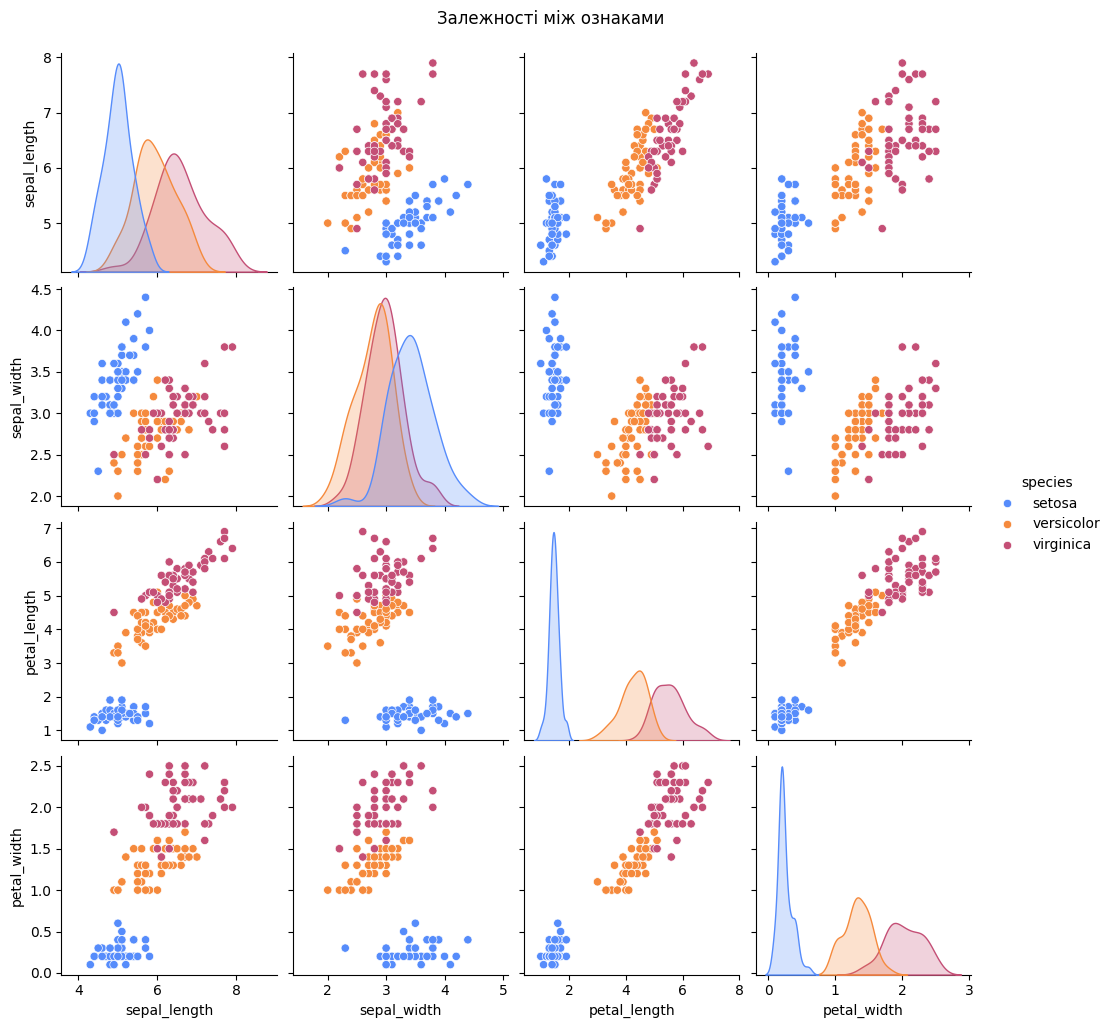

In [15]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
sns.pairplot(data=iris, hue=target_value)

plt.suptitle("Залежності між ознаками", y=1.025)

plt.show()

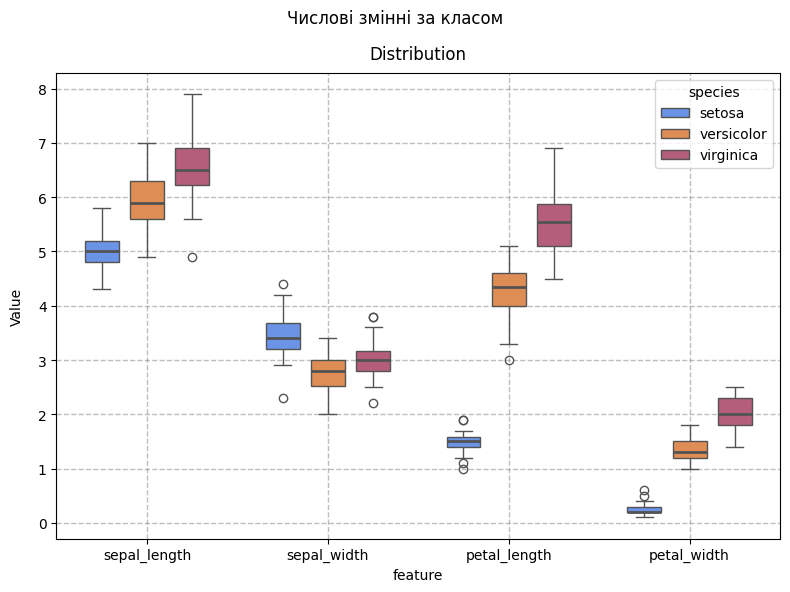

In [16]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(iris_melt_df, ax=ax, x='feature', y='value', hue=target_value,
            width=0.75, gap=0.25, medianprops={'linewidth': 2.0})
# sns.boxplot(iris_melt_df, ax=ax, x=target_value, y='value', hue='feature',
#             width=0.75, gap=0.25, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle("Числові змінні за класом")

plt.tight_layout()
plt.show()

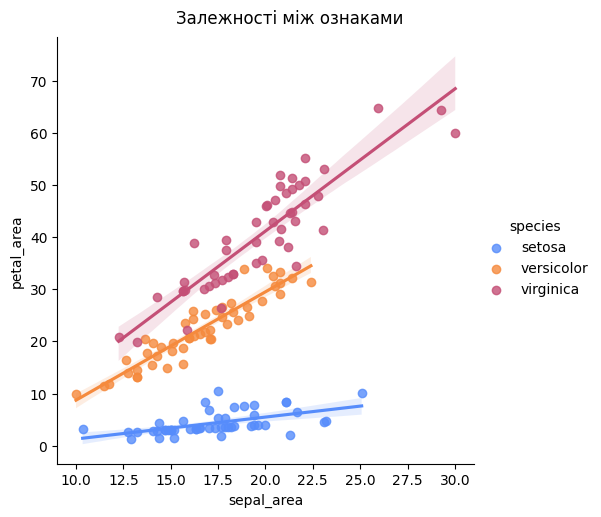

In [17]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
sns.lmplot(data=iris_area, x=sepal_area_col_name, y=petal_area_col_name, hue=target_value)
# sns.lmplot(data=iris_area, y=sepal_area_col_name, x=petal_area_col_name, hue=target_value)

plt.suptitle("Залежності між ознаками", y=1.025)

plt.show()

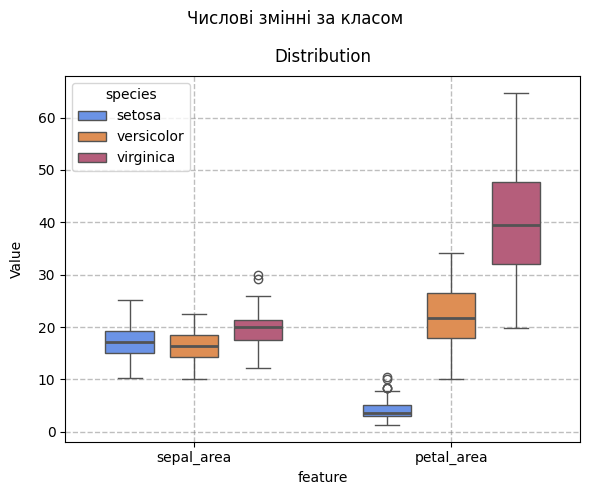

In [18]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(iris_area_melt_df, ax=ax, x='feature', y='value', hue=target_value,
            width=0.75, gap=0.25, medianprops={'linewidth': 2.0})
# sns.boxplot(iris_area_melt_df, ax=ax, x=target_value, y='value', hue='feature',
#             width=0.75, gap=0.25, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle("Числові змінні за класом")

plt.tight_layout()
plt.show()

In [19]:
# 9. Кореляційний аналіз

# Input data

# Solution
params_4_df = iris.drop(columns=[target_value])
params_2_df = iris_area.drop(columns=[target_value])

# Pearson
pearson_matrix_p4 = params_4_df.corr(method='pearson').round(2)
pearson_matrix_p2 = params_2_df.corr(method='pearson').round(2)
# Spearman
spearman_matrix_p4 = params_4_df.corr(method='spearman').round(2)
spearman_matrix_p2 = params_2_df.corr(method='spearman').round(2)

display(Markdown(f"""
### 9. Кореляційний аналіз
---
"""))

display(pearson_matrix_p4.style.set_caption("Pearson (p4)").format(precision=2))
display(pearson_matrix_p2.style.set_caption("Pearson (p2)").format(precision=2))
display(spearman_matrix_p4.style.set_caption("Spearman (p4)").format(precision=2))
display(spearman_matrix_p2.style.set_caption("Spearman (p2)").format(precision=2))

display(Markdown(f"""
---
Відповіді:
> Дуже сильна кореляція проявляється між "petal_length" і "petal_width, сильна кореляція між "sepal_length" і "petal_length"/"petal_width". Тобто пелюстка має пропорційну будову, а довжина чашолистка є практично пропорційна розміру пелюстки та майже завжди збільшується при збільшенні пелюстки.

> Надлишковими ознаками вважаються "petal_length" і "petal_width", оскільки їх коефіцієнт кореляції становить більше 0.9. Щоб зменшити шум у даних, то необхідно вилучити один із параметрів, або ж агрегувати (наприклад, "petal_area").

> На графіках з агрегованими даними помітна помірна кореляція між "sepal_area" і "petal_area", тобто проявляється тенденція, що при збільшенні пелюстки й буде збільшуватися чашолисток. На даному графіку не помітні надлишкові ознаки.
---
"""))


### 9. Кореляційний аналіз
---


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


,sepal_area,petal_area
sepal_area,1.00,0.58
petal_area,0.58,1.00


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.17,0.88,0.83
sepal_width,-0.17,1.00,-0.31,-0.29
petal_length,0.88,-0.31,1.00,0.94
petal_width,0.83,-0.29,0.94,1.00


,sepal_area,petal_area
sepal_area,1.00,0.57
petal_area,0.57,1.00



---
Відповіді:
> Дуже сильна кореляція проявляється між "petal_length" і "petal_width, сильна кореляція між "sepal_length" і "petal_length"/"petal_width". Тобто пелюстка має пропорційну будову, а довжина чашолистка є практично пропорційна розміру пелюстки та майже завжди збільшується при збільшенні пелюстки.

> Надлишковими ознаками вважаються "petal_length" і "petal_width", оскільки їх коефіцієнт кореляції становить більше 0.9. Щоб зменшити шум у даних, то необхідно вилучити один із параметрів, або ж агрегувати (наприклад, "petal_area").

> На графіках з агрегованими даними помітна помірна кореляція між "sepal_area" і "petal_area", тобто проявляється тенденція, що при збільшенні пелюстки й буде збільшуватися чашолисток. На даному графіку не помітні надлишкові ознаки.
---


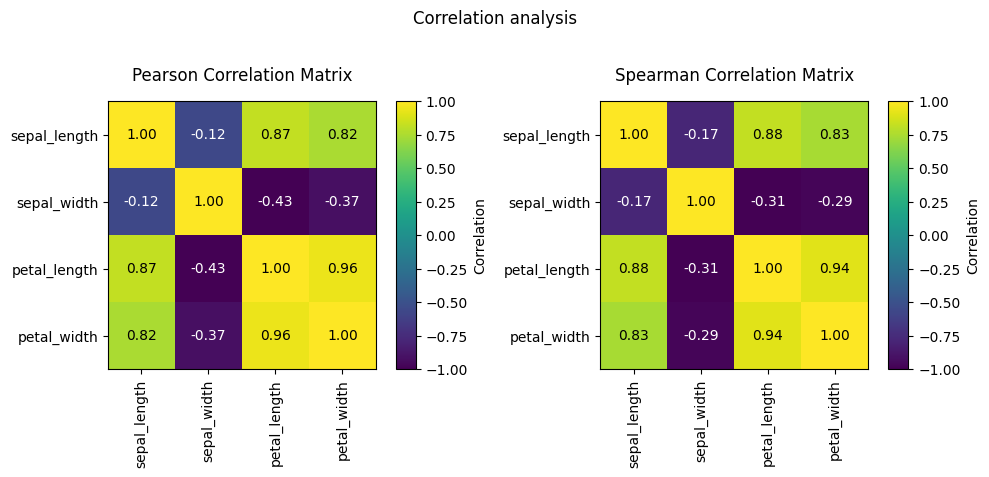

In [20]:
# Graphic results

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data
color_spliter = 0.5

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
data_matrix = pearson_matrix_p4
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.2f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(-1.0, 1.0)
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Pearson Correlation Matrix", pad=15, loc='center', color='black')

ax = axes[1]
data_matrix = spearman_matrix_p4
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.2f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(-1.0, 1.0)
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Spearman Correlation Matrix", pad=15, loc='center', color='black')

plt.suptitle(f"Correlation analysis")

plt.tight_layout()
plt.show()

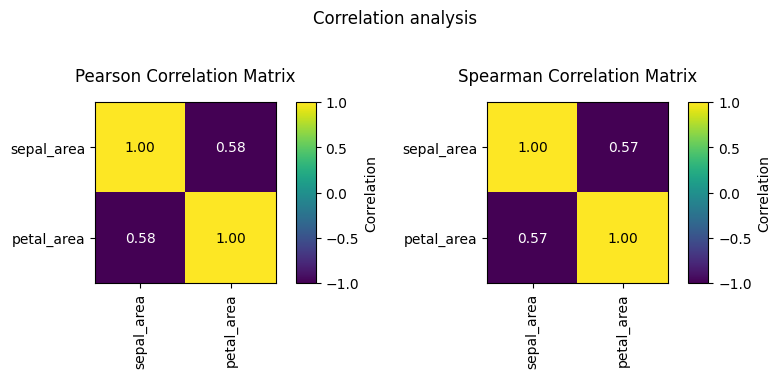

In [21]:
# Graphic results

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data
color_spliter = 0.75

# Solution
_, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes[0]
data_matrix = pearson_matrix_p2
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.2f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(-1.0, 1.0)
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Pearson Correlation Matrix", pad=15, loc='center', color='black')

ax = axes[1]
data_matrix = spearman_matrix_p2
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.2f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(-1.0, 1.0)
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Spearman Correlation Matrix", pad=15, loc='center', color='black')

plt.suptitle(f"Correlation analysis")

plt.tight_layout()
plt.show()

In [30]:
# 10. Зведені таблиці (Pivot Tables)

import pandas as pd

# Input data

# Solution
pivot = pd.pivot_table(iris, index=target_value, aggfunc='mean')
pivot_area = pd.pivot_table(iris_area, index=target_value, aggfunc='mean')

display(Markdown(f"""
### 10. Зведені таблиці (Pivot Tables)
---
Відповіді:
> Відмінності класів між собою. Клас "setosa" має найменші пелюстки (в 5-10 разів менші в порівнянні з іншими) та найширші чашолистки. Аналізуючи умовну площу, вона єдина квітка з наведеної групи, в якої чашолисток більший від пелюстки. Клас "versicolor" має найменші чашолистки. Клас "virginica" є найбільшою квіткою серед наведених, має найбільші пелюстки й чашолистки.
---
"""), pivot, pivot_area, Markdown("---"))


### 10. Зведені таблиці (Pivot Tables)
---
Відповіді:
> Відмінності класів між собою. Клас "setosa" має найменші пелюстки (в 5-10 разів менші в порівнянні з іншими) та найширші чашолистки. Аналізуючи умовну площу, вона єдина квітка з наведеної групи, в якої чашолисток більший від пелюстки. Клас "versicolor" має найменші чашолистки. Клас "virginica" є найбільшою квіткою серед наведених, має найбільші пелюстки й чашолистки.
---


,petal_length,petal_width,sepal_length,sepal_width
species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


,petal_area,sepal_area
species,,
setosa,4.32644,17.2578
versicolor,22.29632,16.5262
virginica,40.32054,19.6846


---

In [38]:
# 11. Виявлення закономірностей

# Input data

# Solution
display(Markdown(f"""
### 11. Виявлення закономірностей
---
Опис:

> Найважливішими ознаками є "petal_..." через те, що вони чітко виділяють класи на графіках (різниця помітна в рази), тобто не мають перетинів між класами. Важливими є визначення характеристик трендових ліній розподілу площ пелюсток і чашолистиків, за якими можна в більшості випадків спрогнозувати клас квітки.

> Класи легко розділяються за розміром пелюстки. Клас "setosa" легко відділяється, на відміну від "versicolor" та "virginica", які трохи перекриваються.
---
"""))


### 11. Виявлення закономірностей
---
Опис:

> Найважливішими ознаками є "petal_..." через те, що вони чітко виділяють класи на графіках (різниця помітна в рази), тобто не мають перетинів між класами. Важливими є визначення характеристик трендових ліній розподілу площ пелюсток і чашолистиків, за якими можна в більшості випадків спрогнозувати клас квітки.
> Клас "setosa" легко відділяється, на відміну від "versicolor" та "virginica", які трохи перекриваються.
---


In [41]:
# 12. Висновки

# Input data

# Solution
display(Markdown(f"""
### 12. Висновки
---
Висновки:
> Структура: Датасет чистий, без пропусків, та ідеально збалансований.
> Маємо 4 ознаки, які можна перетворити у 2 агреговані ознаки та одна категоріальна/цільова змінна.
> Використання площі (area) замість її параметрів (довжина та ширина) допомогло уникнути надлишковості (шуму).
> Виявлено сильний кореляційний звʼязок параметрів пелюстки.
> Ознака "sepal_width" має найменшу кореляцію з іншими ознаками.
> Клас "setosa" — унікальний вид, який легко ідентифікувати, який є найменшим по розмірах.
> Параметри пелюсток (petal) є набагато інформативнішими для класифікації, ніж параметри чашолистків (sepal).
---
"""))


### 12. Висновки
---
Висновки:
> Структура: Датасет чистий, без пропусків, та ідеально збалансований.
> Маємо 4 ознаки, які можна перетворити у 2 агреговані ознаки та одна категоріальна/цільова змінна.
> Використання площі (area) замість її параметрів (довжина та ширина) допомогло уникнути надлишковості (шуму).
> Виявлено сильний кореляційний звʼязок параметрів пелюстки.
> Ознака "sepal_width" має найменшу кореляцію з іншими ознаками.
> Клас "setosa" — унікальний вид, який легко ідентифікувати, який є найменшим по розмірах.
> Параметри пелюсток (petal) є набагато інформативнішими для класифікації, ніж параметри чашолистків (sepal).
---
